# S1 — Validated deterministic scoring: the validation, regenerated

*Legacy id 13_3 (File A §10 Phase 14).* This notebook regenerates study S1's results — WP-6's signed `validate_formula` run — from the replication export alone, and checks every regenerated file against the signed copy.

- **Input:** `research_data/exports/`, written by `python manage.py export_research_data` (see `REPLICATION.md`). No database is opened, and nothing is fetched: deps.dev's Scorecards and the anchor scan are read as WP-6 observed them.
- **Every score is recomputed** from the stored signals through the product's own engine (D6, File C §1.1). The stored score is read once, to prove the recomputation reproduces it.
- **Limitations that travel with these numbers** (REPLICATION.md §6): the AHP matrix is a single judgment; the PyPI vector is a reasoned shift of the npm one; the corpus is one cross-section (2026-10-07), so nothing here supports a temporal claim; H1 and H2 are not supported (decisions §12.18).

In [1]:
import os
import sys
from pathlib import Path

# The repository root, wherever Jupyter was started from inside it.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "backend" / "manage.py").exists())
sys.path.insert(0, str(ROOT / "backend"))
# Exports only, never a database: this settings module's database backend
# raises on the first query (config/settings/offline.py).
os.environ["DJANGO_SETTINGS_MODULE"] = "config.settings.offline"

import django

django.setup()

from IPython.display import Image, Markdown, display

from apps.research import replication

EXPORT = replication.find_export(ROOT)  # or set RV_EXPORTS
# Regenerated files go here, never over the export.
WORK = Path(os.environ.get("RV_NOTEBOOK_WORK", ROOT / "research_data" / "notebook_work")) / "13_3_validation"


def shown(path):
    """A path as the reader's checkout would print it."""
    path = Path(path)
    return path.relative_to(ROOT).as_posix() if path.is_relative_to(ROOT) else str(path)


print("export:", shown(EXPORT))

export: research_data/exports


## 1. The export is what was exported

In [2]:
check = replication.verify_export(EXPORT)
display(Markdown(replication.manifest_summary(check.manifest)))
assert check.ok, f"changed: {check.mismatched}; missing: {check.missing}"
print(f"{check.checked} files match the sha256 the export recorded")

| | |
|---|---|
| Exported | 2026-10-10T03:49:31Z |
| At commit | `0c4a5038d445` |
| Database | postgresql `repovitals_research` |
| Sources | corpus_scan |
| `scan_history` | 914 rows (2026-10-07 914) |
| `dependency_history` | 29494 rows |
| `agent_traces` | 0 rows |
| Files | 51, each with its sha256 |

51 files match the sha256 the export recorded


## 2. The corpus panel, and D6's reproduction check

The panel is built from `scan_history.parquet` and `dependency_history.parquet` by the same constructor the harness uses (`panel.build_panel`), in the repository order WP-6 resampled in — read from its own `scores.csv`, because the database's collation decided that order (decisions §14).

In [3]:
from apps.research.validation import panel as panels
from apps.scoring.weights import load_weights

SIGNED = EXPORT / "validation_report"
corpus = replication.panel_from_export(EXPORT, order=replication.validation_order(SIGNED))
reproduced = panels.reproduction_check(corpus, load_weights)
print(
    f"{len(corpus.repositories)} repositories, {corpus.occurrence_count} occurrences "
    f"as of {corpus.snapshot_date}"
)
print(f"stored scores reproduced under their own version: {reproduced.matched}/{reproduced.checked}")
assert reproduced.all_match, reproduced.mismatches

914 repositories, 29494 occurrences as of 2026-10-07
stored scores reproduced under their own version: 914/914


## 3. The corpus under every weights file

`v0_equal` is §7's naive baseline, `v1` scored every stored row, `v2` is the vector WP-6 signed (decisions §12.19). Unweighted counts; File C §1.3 asks for the sampling-weighted versions in the papers.

In [4]:
display(Markdown(replication.classification_table(corpus, ["v0_equal", "v1", "v2"])))

| Weights | Derivation | Safe | Medium | High alert | Median score |
|---|---|---|---|---|---|
| `v0_equal` | bootstrap-equal | 136 | 278 | 500 | 42.66 |
| `v1` | informal-pairwise | 273 | 143 | 498 | 43.74 |
| `v2` | ahp-entropy-validated | 300 | 144 | 470 | 46.45 |

## 4. WP-6's validation run, again

`rerun_validation` reads the signed run's `inputs.json` — matrix and anchor set (checked by sha256), snapshot, baseline, PyPI rule, seed, bootstrap — and runs `harness.run_validation` on the exported panel, then writes the report folder with the harness's own writer. Every text file is compared with the signed one, skipping only the lines that state when a file was generated. *Equal to float precision* means full-precision CSV cells that differ in their last digits: Python 3.12 made `sum()` compensated, and the signed run used 3.11, which regenerates them byte for byte (REPLICATION.md §5).

In [5]:
run = replication.rerun_validation(
    EXPORT, WORK / "validation_report", progress=lambda line: print(line.replace(str(ROOT) + "/", ""))
)
results = replication.compare_folders(
    WORK / "validation_report", SIGNED, list(replication.VALIDATION_FILES)
)
display(Markdown(replication.comparison_table(results)))
assert all(result.identical for result in results), [r.differences for r in results if not r.identical]

AHP: research_data/exports/ahp/wp3_matrix_final.csv
corpus: 914 repositories, 29494 occurrences as of 2026-10-07


deps.dev: Scorecard for 914 repositories (cached)


sensitivity: sweeping both vectors


anchors: reusing the scan of 2026-10-08T03:26:42.942451+00:00


| File | Against the signed copy |
|---|---|
| `report.md` | **identical** |
| `inputs.json` | **identical** |
| `weights_v2_candidate.yaml` | **identical** |
| `scores.csv` | **identical** |
| `entropy.csv` | **identical** |
| `weights_comparison.csv` | **identical** |
| `correlation.csv` | **identical** |
| `confusion.csv` | **identical** |
| `sensitivity.csv` | **identical** |
| `anchors.csv` | **identical** |

### The regenerated report

In [6]:
text = (WORK / "validation_report" / "report.md").read_text(encoding="utf-8")
# The figures are shown below; their relative links do not resolve here.
display(Markdown("\n".join(line for line in text.splitlines() if not line.startswith("!["))))

# S1 validation report

Generated by `manage.py validate_formula` (§10 Phase 12) on 2026-10-10T03:50:09Z. Every score below is **recomputed** from the stored signals of one corpus snapshot through the shipped engine (D6, File C §1.1); no stored score is read as a result and no row was written.

## Inputs

| | |
|---|---|
| Corpus snapshot | `2026-10-07`: 914 repositories, 29494 occurrences |
| Reconciled AHP matrix | `wp3_matrix_final.csv` (sha256 `7228688575b28589…`) |
| Anchor set | `wp2_anchor_set.csv` (sha256 `a02e6fa890707c8b…`) |
| Baseline weights | `v1` (informal-pairwise) |
| Seed / bootstrap | 42 / 2000 resamples of repositories |

**Reproduction check (D6).** All 914 stored repository scores reproduce exactly when recomputed under the version on their own row.

## WP-6 sign-off checklist

File B WP-6's six items. `wp6_signoff.md` walks each one.

| # | Check | Status | Detail |
|---|---|---|---|
| 1 | Reconciled matrix CR < 0.10 | **ok** | CR = 0.0054 (λ_max 4.0145, CI 0.0048, RI 0.90). |
| 2 | Every known anchor ≥ Medium | **ok** | 12 of 12 known anchors pass. |
| 3 | AHP vs entropy: broad agreement, or the disagreement acknowledged | **attention** | npm: cosine 0.898 (partial), top two differ; pypi: cosine 0.691 (tension), top two differ. Disagreement is not a failure (File C §2.4.2) but the sign-off must discuss it. |
| 4 | Correlation vs deps.dev Scorecard positive and non-trivial | **attention** | Spearman rho = 0.047 [-0.077, 0.169] over 289 of 914 repositories with a Scorecard. The OSV roll-up's circularity caveat is printed beside its number in RQ2 (OSV rho = 0.863). |
| 5 | Sensitivity: flip rate under 15% at ±10-20%, both vectors | **ok** | v2-candidate (AHP): max flip rate 1.4% at ±10%, 4.7% at ±20%; entropy: max flip rate 1.9% at ±10%, 3.8% at ±20%. |
| 6 | Final vectors sum to 1 and are non-degenerate | **ok** | npm 0.2720 / 0.4829 / 0.1570 / 0.0881; pypi 0.1904 / 0.5237 / 0.1570 / 0.1289 (deprecation / severity / count / staleness). |

## RQ1 — Do subjective (AHP) and objective (entropy) weights agree?

### The reconciled AHP matrix

| | Deprecation | Severity | Count | Staleness |
|---|---|---|---|---|
| Deprecation | 1 | 1/2 | 2 | 3 |
| Severity | 2 | 1 | 3 | 5 |
| Count | 1/2 | 1/3 | 1 | 2 |
| Staleness | 1/3 | 1/5 | 1/2 | 1 |

Principal eigenvector: Deprecation **0.2720**, Severity **0.4829**, Count **0.1570**, Staleness **0.0882**. λ_max = 4.0145, CI = 0.0048, RI = 0.90, **CR = 0.0054**.


**PyPI.** PyPI vector = the AHP vector shifted by deprecation -0.0816, severity +0.0408, staleness +0.0408 (--pypi-shift; File C limitation L4: reasoned redistribution in the same session, not an independent calibration).

### Entropy weights from the corpus

Over every assessable occurrence of the snapshot, normalised exactly as the formula normalises it. A missing staleness is left out of that column only (§5.2). Intervals: 95% repository-cluster bootstrap.

| Ecosystem | Signal | Rows | Non-zero | Entropy | Weight | 95% interval | Weight (sampling-weighted) |
|---|---|---|---|---|---|---|---|
| npm | deprecation | 19881 | 1309 | 0.7251 | 0.2884 | [0.274, 0.303] | 0.3015 |
| npm | severity | 19881 | 1155 | 0.7092 | 0.3051 | [0.296, 0.314] | 0.2964 |
| npm | count | 19881 | 1155 | 0.6758 | 0.3402 | [0.331, 0.349] | 0.3295 |
| npm | staleness | 17982 | 17418 | 0.9368 | 0.0663 | [0.062, 0.071] | 0.0727 |
| pypi | deprecation | 8922 | 48 | 0.4256 | 0.5149 | [0.491, 0.539] | 0.5129 |
| pypi | severity | 8922 | 1251 | 0.7811 | 0.1962 | [0.185, 0.209] | 0.1967 |
| pypi | count | 8922 | 1251 | 0.7616 | 0.2137 | [0.202, 0.226] | 0.2145 |
| pypi | staleness | 8908 | 8732 | 0.9162 | 0.0752 | [0.071, 0.078] | 0.0759 |

### Agreement

| Vectors | Cosine | Band | Spearman (weights) | Order (first) | Order (second) | Largest gap |
|---|---|---|---|---|---|---|
| v2-candidate (AHP) [npm] vs entropy [npm] | 0.898 | partial | 0.400 | severity > deprecation > count > staleness | count > severity > deprecation > staleness | count +0.183 |
| v1 [npm] vs entropy [npm] | 0.899 | partial | 0.200 | deprecation > severity > count > staleness | count > severity > deprecation > staleness | count +0.180 |
| v2-candidate (AHP) [pypi] vs entropy [pypi] | 0.691 | tension | 0.400 | severity > deprecation > count > staleness | deprecation > count > severity > staleness | severity -0.327 |
| v1 [pypi] vs entropy [pypi] | 0.890 | partial | 0.000 | severity > deprecation > staleness > count | deprecation > count > severity > staleness | deprecation +0.195 |

File C H1: cosine ≥ 0.90 *and* the same top two signals. Entropy weights a signal by how unevenly it is spread, so a rare-but-decisive signal such as deprecation can carry more entropy weight than a judge gives it, or less if the judge weighs its severity: a divergence there is interpretable (File C §2.4.2), and a cosine below 0.75 leads the discussion.

## RQ2 — Do the scores converge with an independent reference?

> OpenSSF Scorecard (via deps.dev) rates a repository's security practices, not its dependencies' risk: an independent but different construct (File C L2). A moderate positive correlation is the expected result (H2: Spearman rho between 0.3 and 0.6); it is evidence of convergent validity, not of accuracy.

> Circular reference: OSV supplies two of the formula's four signals (severity and count), so agreement with an OSV severity roll-up is partly the formula agreeing with its own inputs (File C L1). Reported beside the independent reference, never instead of it.

Repository score (higher is healthier) against each reference, oriented so a positive correlation is the expected direction. Intervals: 95% percentile bootstrap over repositories. The weighted column applies `sampling_weight` (File C §1.3); the unweighted value is the primary one.

| Formula | Reference | Group | Covered | Spearman rho | 95% interval | Pearson r | 95% interval | rho weighted | r weighted |
|---|---|---|---|---|---|---|---|---|---|
| v1 | Scorecard (independent) | all | 289/914 | 0.084 | [-0.034, 0.204] | 0.054 | [-0.069, 0.168] | 0.073 | 0.043 |
| v1 | Scorecard (independent) | npm | 162/475 | 0.061 | [-0.091, 0.206] | 0.079 | [-0.086, 0.243] | 0.135 | 0.149 |
| v1 | Scorecard (independent) | pypi | 115/402 | 0.142 | [-0.042, 0.317] | 0.101 | [-0.086, 0.287] | 0.028 | -0.065 |
| v1 | OSV roll-up (circular) | all | 914/914 | 0.673 | [0.636, 0.707] | 0.704 | [0.667, 0.740] | 0.684 | 0.714 |
| v1 | OSV roll-up (circular) | npm | 475/475 | 0.561 | [0.497, 0.620] | 0.574 | [0.515, 0.632] | 0.574 | 0.595 |
| v1 | OSV roll-up (circular) | pypi | 402/402 | 0.845 | [0.818, 0.867] | 0.888 | [0.860, 0.911] | 0.874 | 0.911 |
| v2-candidate (AHP) | Scorecard (independent) | all | 289/914 | 0.047 | [-0.077, 0.169] | 0.022 | [-0.106, 0.141] | 0.006 | -0.024 |
| v2-candidate (AHP) | Scorecard (independent) | npm | 162/475 | -0.017 | [-0.175, 0.141] | 0.038 | [-0.124, 0.194] | 0.034 | 0.085 |
| v2-candidate (AHP) | Scorecard (independent) | pypi | 115/402 | 0.132 | [-0.052, 0.313] | 0.109 | [-0.055, 0.273] | 0.028 | -0.028 |
| v2-candidate (AHP) | OSV roll-up (circular) | all | 914/914 | 0.863 | [0.850, 0.873] | 0.890 | [0.875, 0.904] | 0.868 | 0.894 |
| v2-candidate (AHP) | OSV roll-up (circular) | npm | 475/475 | 0.828 | [0.802, 0.850] | 0.826 | [0.798, 0.853] | 0.829 | 0.834 |
| v2-candidate (AHP) | OSV roll-up (circular) | pypi | 402/402 | 0.871 | [0.851, 0.887] | 0.956 | [0.946, 0.964] | 0.891 | 0.964 |
| entropy | Scorecard (independent) | all | 289/914 | 0.060 | [-0.063, 0.179] | 0.025 | [-0.100, 0.140] | 0.026 | -0.017 |
| entropy | Scorecard (independent) | npm | 162/475 | 0.007 | [-0.146, 0.158] | 0.046 | [-0.110, 0.197] | 0.056 | 0.090 |
| entropy | Scorecard (independent) | pypi | 115/402 | 0.131 | [-0.051, 0.312] | 0.083 | [-0.130, 0.271] | 0.013 | -0.130 |
| entropy | OSV roll-up (circular) | all | 914/914 | 0.751 | [0.724, 0.774] | 0.775 | [0.747, 0.801] | 0.765 | 0.788 |
| entropy | OSV roll-up (circular) | npm | 475/475 | 0.780 | [0.745, 0.811] | 0.783 | [0.748, 0.815] | 0.786 | 0.793 |
| entropy | OSV roll-up (circular) | pypi | 402/402 | 0.821 | [0.783, 0.850] | 0.840 | [0.790, 0.881] | 0.851 | 0.866 |

deps.dev coverage: no_scorecard 157, not_found 468, ok 289.

### Three-class agreement (Cohen's kappa), under three cuts of the reference

| Formula | Reference | Group | kappa tertiles | kappa matched proportions | kappa equal thirds of 0-10 |
|---|---|---|---|---|---|
| v1 | Scorecard (independent) | all | 0.005 | 0.027 | -0.040 |
| v1 | Scorecard (independent) | npm | -0.015 | 0.002 | -0.024 |
| v1 | Scorecard (independent) | pypi | 0.050 | 0.039 | -0.009 |
| v1 | OSV roll-up (circular) | all | 0.259 | 0.365 | 0.492 |
| v1 | OSV roll-up (circular) | npm | 0.102 | 0.269 | 0.390 |
| v1 | OSV roll-up (circular) | pypi | 0.396 | 0.502 | 0.595 |
| v2-candidate (AHP) | Scorecard (independent) | all | 0.031 | 0.034 | 0.004 |
| v2-candidate (AHP) | Scorecard (independent) | npm | -0.029 | -0.030 | 0.038 |
| v2-candidate (AHP) | Scorecard (independent) | pypi | 0.139 | 0.035 | 0.006 |
| v2-candidate (AHP) | OSV roll-up (circular) | all | 0.347 | 0.479 | 0.589 |
| v2-candidate (AHP) | OSV roll-up (circular) | npm | 0.292 | 0.421 | 0.480 |
| v2-candidate (AHP) | OSV roll-up (circular) | pypi | 0.340 | 0.588 | 0.709 |
| entropy | Scorecard (independent) | all | 0.022 | 0.026 | -0.013 |
| entropy | Scorecard (independent) | npm | -0.027 | -0.015 | 0.036 |
| entropy | Scorecard (independent) | pypi | 0.077 | 0.015 | -0.010 |
| entropy | OSV roll-up (circular) | all | 0.197 | 0.482 | 0.565 |
| entropy | OSV roll-up (circular) | npm | 0.260 | 0.398 | 0.460 |
| entropy | OSV roll-up (circular) | pypi | 0.125 | 0.697 | 0.674 |

Confusion, v2-candidate (AHP) vs Scorecard (independent) (tertiles), rows = formula class, columns = reference bucket:

| | high_alert | medium | safe |
|---|---|---|---|
| high_alert | 52 | 35 | 42 |
| medium | 21 | 18 | 17 |
| safe | 43 | 24 | 37 |

A kappa that moves a lot between cuts is a statement about the cut, not the formula (§10 Phase 12's bucketing-choice sensitivity).

## RQ3 — Do classifications survive perturbation?

One parameter at a time; a flip is a change of class against the same vector unperturbed. Weight changes are renormalised so the four weights still sum to 1. File C H3: under 15% flips at ±20%; any parameter over 20% gets its own paragraph.

- **v2-candidate (AHP)**: max weight-perturbation flip rate 1.4% at ±10%, 4.7% at ±20% (robust by H3); max over every parameter 8.1%.
- **entropy**: max weight-perturbation flip rate 1.9% at ±10%, 3.8% at ±20% (robust by H3); max over every parameter 3.8%.

| Vector | Parameter | Change | Flips | Rate | npm | pypi | mixed |
|---|---|---|---|---|---|---|---|
| v2-candidate (AHP) | weight:deprecation | -20% | 19/914 | 2.1% | 13/475 | 6/402 | 0/37 |
| v2-candidate (AHP) | weight:deprecation | -10% | 7/914 | 0.8% | 5/475 | 2/402 | 0/37 |
| v2-candidate (AHP) | weight:deprecation | +10% | 2/914 | 0.2% | 1/475 | 1/402 | 0/37 |
| v2-candidate (AHP) | weight:deprecation | +20% | 8/914 | 0.9% | 3/475 | 5/402 | 0/37 |
| v2-candidate (AHP) | weight:severity | -20% | 18/914 | 2.0% | 6/475 | 12/402 | 0/37 |
| v2-candidate (AHP) | weight:severity | -10% | 9/914 | 1.0% | 1/475 | 8/402 | 0/37 |
| v2-candidate (AHP) | weight:severity | +10% | 8/914 | 0.9% | 4/475 | 4/402 | 0/37 |
| v2-candidate (AHP) | weight:severity | +20% | 29/914 | 3.2% | 12/475 | 17/402 | 0/37 |
| v2-candidate (AHP) | weight:count | -20% | 4/914 | 0.4% | 1/475 | 3/402 | 0/37 |
| v2-candidate (AHP) | weight:count | -10% | 2/914 | 0.2% | 0/475 | 2/402 | 0/37 |
| v2-candidate (AHP) | weight:count | +10% | 2/914 | 0.2% | 1/475 | 1/402 | 0/37 |
| v2-candidate (AHP) | weight:count | +20% | 4/914 | 0.4% | 3/475 | 1/402 | 0/37 |
| v2-candidate (AHP) | weight:staleness | -20% | 31/914 | 3.4% | 2/475 | 29/402 | 0/37 |
| v2-candidate (AHP) | weight:staleness | -10% | 13/914 | 1.4% | 0/475 | 13/402 | 0/37 |
| v2-candidate (AHP) | weight:staleness | +10% | 10/914 | 1.1% | 0/475 | 10/402 | 0/37 |
| v2-candidate (AHP) | weight:staleness | +20% | 43/914 | 4.7% | 25/475 | 18/402 | 0/37 |
| v2-candidate (AHP) | rollup.decay | -20% (0.4) | 31/914 | 3.4% | 11/475 | 19/402 | 1/37 |
| v2-candidate (AHP) | rollup.decay | -10% (0.45) | 11/914 | 1.2% | 4/475 | 6/402 | 1/37 |
| v2-candidate (AHP) | rollup.decay | +10% (0.55) | 8/914 | 0.9% | 3/475 | 5/402 | 0/37 |
| v2-candidate (AHP) | rollup.decay | +20% (0.6) | 41/914 | 4.5% | 30/475 | 11/402 | 0/37 |
| v2-candidate (AHP) | rollup.max_terms | -20% (16) | 0/914 | 0.0% | 0/475 | 0/402 | 0/37 |
| v2-candidate (AHP) | rollup.max_terms | -10% (18) | 0/914 | 0.0% | 0/475 | 0/402 | 0/37 |
| v2-candidate (AHP) | rollup.max_terms | +10% (22) | 0/914 | 0.0% | 0/475 | 0/402 | 0/37 |
| v2-candidate (AHP) | rollup.max_terms | +20% (24) | 0/914 | 0.0% | 0/475 | 0/402 | 0/37 |
| v2-candidate (AHP) | thresholds.safe_min | -5 (75) | 37/914 | 4.0% | 0/475 | 37/402 | 0/37 |
| v2-candidate (AHP) | thresholds.safe_min | +5 (85) | 74/914 | 8.1% | 44/475 | 29/402 | 1/37 |
| v2-candidate (AHP) | thresholds.medium_min | -5 (45) | 23/914 | 2.5% | 15/475 | 7/402 | 1/37 |
| v2-candidate (AHP) | thresholds.medium_min | +5 (55) | 8/914 | 0.9% | 6/475 | 2/402 | 0/37 |
| entropy | weight:deprecation | -20% | 35/914 | 3.8% | 18/475 | 16/402 | 1/37 |
| entropy | weight:deprecation | -10% | 17/914 | 1.9% | 7/475 | 10/402 | 0/37 |
| entropy | weight:deprecation | +10% | 9/914 | 1.0% | 2/475 | 7/402 | 0/37 |
| entropy | weight:deprecation | +20% | 21/914 | 2.3% | 7/475 | 13/402 | 1/37 |
| entropy | weight:severity | -20% | 17/914 | 1.9% | 7/475 | 10/402 | 0/37 |
| entropy | weight:severity | -10% | 7/914 | 0.8% | 3/475 | 4/402 | 0/37 |
| entropy | weight:severity | +10% | 13/914 | 1.4% | 6/475 | 7/402 | 0/37 |
| entropy | weight:severity | +20% | 19/914 | 2.1% | 10/475 | 9/402 | 0/37 |
| entropy | weight:count | -20% | 14/914 | 1.5% | 7/475 | 7/402 | 0/37 |
| entropy | weight:count | -10% | 4/914 | 0.4% | 3/475 | 1/402 | 0/37 |
| entropy | weight:count | +10% | 8/914 | 0.9% | 4/475 | 4/402 | 0/37 |
| entropy | weight:count | +20% | 16/914 | 1.8% | 9/475 | 7/402 | 0/37 |
| entropy | weight:staleness | -20% | 4/914 | 0.4% | 2/475 | 2/402 | 0/37 |
| entropy | weight:staleness | -10% | 1/914 | 0.1% | 0/475 | 1/402 | 0/37 |
| entropy | weight:staleness | +10% | 4/914 | 0.4% | 2/475 | 2/402 | 0/37 |
| entropy | weight:staleness | +20% | 5/914 | 0.5% | 2/475 | 3/402 | 0/37 |
| entropy | rollup.decay | -20% (0.4) | 32/914 | 3.5% | 21/475 | 10/402 | 1/37 |
| entropy | rollup.decay | -10% (0.45) | 11/914 | 1.2% | 5/475 | 6/402 | 0/37 |
| entropy | rollup.decay | +10% (0.55) | 13/914 | 1.4% | 6/475 | 7/402 | 0/37 |
| entropy | rollup.decay | +20% (0.6) | 24/914 | 2.6% | 9/475 | 14/402 | 1/37 |
| entropy | rollup.max_terms | -20% (16) | 0/914 | 0.0% | 0/475 | 0/402 | 0/37 |
| entropy | rollup.max_terms | -10% (18) | 0/914 | 0.0% | 0/475 | 0/402 | 0/37 |
| entropy | rollup.max_terms | +10% (22) | 0/914 | 0.0% | 0/475 | 0/402 | 0/37 |
| entropy | rollup.max_terms | +20% (24) | 0/914 | 0.0% | 0/475 | 0/402 | 0/37 |
| entropy | thresholds.safe_min | -5 (75) | 10/914 | 1.1% | 3/475 | 7/402 | 0/37 |
| entropy | thresholds.safe_min | +5 (85) | 10/914 | 1.1% | 1/475 | 9/402 | 0/37 |
| entropy | thresholds.medium_min | -5 (45) | 34/914 | 3.7% | 22/475 | 11/402 | 1/37 |
| entropy | thresholds.medium_min | +5 (55) | 26/914 | 2.8% | 9/475 | 15/402 | 2/37 |

## RQ4 — Do the known-bad anchors classify as at least Medium?

Scanned 2026-10-08T03:26:42Z, current state, through the corpus pipeline; nothing registered. A known anchor passes only if its repository is ≥ Medium **and** the scan saw the anchor package at the named version, flagged.

| Repository | Bucket | Known anchor | Seen at version | Flags | v1 | v2-candidate (AHP) | Verdict |
|---|---|---|---|---|---|---|---|
| `atom/atom` | risky | postcss@8.2.10 | yes (lockfile) | vulnerable | 0.00 (high_alert) | 0.00 (high_alert) | pass |
| `atom/apm` | risky | request@2.88.2 | yes (lockfile) | deprecated, vulnerable, stale | 0.00 (high_alert) | 0.00 (high_alert) | pass |
| `angular/angular.js` | risky | karma@4.4.1 | yes (pinned) | vulnerable, stale | 0.00 (high_alert) | 0.00 (high_alert) | pass |
| `angular/protractor` | risky | lodash@4.17.11 | yes (lockfile) | vulnerable | 0.00 (high_alert) | 0.00 (high_alert) | pass |
| `microsoft/vscode-go` | risky | tslint@6.1.1 | yes (lockfile) | deprecated, stale | 0.00 (high_alert) | 23.27 (high_alert) | pass |
| `facebookarchive/react-native-fbsdk` | risky | eslint@7.14.0 | yes (pinned) | deprecated | 3.11 (high_alert) | 37.96 (high_alert) | pass |
| `bower/bower` | risky | request@2.67.0 | yes (pinned) | deprecated, vulnerable, stale | 0.00 (high_alert) | 0.00 (high_alert) | pass |
| `facebookarchive/flux` | risky |  |  |  | 0.00 (high_alert) | 28.12 (high_alert) |  |
| `react/create-react-app` | risky |  |  |  | 0.00 (high_alert) | 0.00 (high_alert) |  |
| `request/request` | risky |  |  |  | 0.00 (high_alert) | 31.38 (high_alert) |  |
| `strongloop/loopback` | risky |  |  |  | 34.00 (high_alert) | 55.18 (medium) |  |
| `openai/gpt-2` | risky | requests@2.21.0 | yes (pinned) | vulnerable | 53.31 (medium) | 40.59 (high_alert) | pass |
| `Netflix/security_monkey` | risky | PyYAML@5.3 | yes (pinned) | vulnerable | 1.83 (high_alert) | 0.00 (high_alert) | pass |
| `mdn/kuma` | risky | django@3.2.12 | yes (lockfile) | vulnerable | 0.00 (high_alert) | 0.00 (high_alert) | pass |
| `openai/jukebox` | risky | tqdm@4.45.0 | yes (pinned) | vulnerable | 74.42 (medium) | 69.81 (medium) | pass |
| `googleapis/oauth2client` | risky | Django@1.10.0 | yes (pinned) | vulnerable | 0.00 (high_alert) | 0.00 (high_alert) | pass |
| `tensorflow/tensor2tensor` | risky |  |  |  | 32.79 (high_alert) | 47.63 (high_alert) |  |
| `YelpArchive/elastalert` | risky |  |  |  | 66.00 (medium) | 74.22 (medium) |  |
| `openai/spinningup` | risky |  |  |  | 33.62 (high_alert) | 20.79 (high_alert) |  |
| `boto/boto` | risky |  |  |  | 13.11 (high_alert) | 0.00 (high_alert) |  |
| `eslint/eslint` | healthy |  |  |  | 80.00 (safe) | 82.38 (safe) |  |
| `prettier/prettier` | healthy |  |  |  | 71.57 (medium) | 60.86 (medium) |  |
| `vercel/next.js` | healthy |  |  |  | 0.00 (high_alert) | 0.00 (high_alert) |  |
| `microsoft/vscode` | healthy |  |  |  | 0.00 (high_alert) | 11.96 (high_alert) |  |
| `microsoft/TypeScript` | healthy |  |  |  | 95.29 (safe) | 95.85 (safe) |  |
| `mochajs/mocha` | healthy |  |  |  | 74.27 (medium) | 65.36 (medium) |  |
| `expressjs/express` | healthy |  |  |  | 43.95 (high_alert) | 63.95 (medium) |  |
| `axios/axios` | healthy |  |  |  | 71.86 (medium) | 61.09 (medium) |  |
| `mozilla/pdf.js` | healthy |  |  |  | 72.87 (medium) | 78.41 (medium) |  |
| `django/django` | healthy |  |  |  | 66.59 (medium) | 74.66 (medium) |  |
| `pallets/flask` | healthy |  |  |  | 8.51 (high_alert) | 0.00 (high_alert) |  |
| `celery/celery` | healthy |  |  |  | 19.98 (high_alert) | 33.32 (high_alert) |  |
| `pytest-dev/pytest` | healthy |  |  |  | 66.39 (medium) | 74.53 (medium) |  |
| `psf/requests` | healthy |  |  |  | 73.86 (medium) | 80.17 (safe) |  |
| `scrapy/scrapy` | healthy |  |  |  | 12.70 (high_alert) | 0.00 (high_alert) |  |
| `python-poetry/poetry` | healthy |  |  |  | 42.82 (high_alert) | 33.64 (high_alert) |  |
| `pypa/pipenv` | healthy |  |  |  | 68.96 (medium) | 76.47 (medium) |  |
| `gulpjs/gulp` | in_between |  |  |  | 80.97 (safe) | 83.24 (safe) |  |
| `jaredhanson/passport` | in_between |  |  |  | 80.15 (safe) | 82.51 (safe) |  |
| `moment/moment` | in_between |  |  |  | 85.62 (safe) | 87.33 (safe) |  |
| `pugjs/pug` | in_between |  |  |  | 80.00 (safe) | 82.38 (safe) |  |
| `jquery/jquery-ui` | in_between |  |  |  | 80.03 (safe) | 82.41 (safe) |  |
| `bevacqua/dragula` | in_between |  |  |  | 80.00 (safe) | 82.38 (safe) |  |
| `rstacruz/nprogress` | in_between |  |  |  | 88.77 (safe) | 90.10 (safe) |  |
| `dropbox/pyannotate` | in_between |  |  |  | 69.77 (medium) | 77.07 (medium) |  |
| `kennethreitz/records` | in_between |  |  |  | 75.62 (medium) | 81.51 (safe) |  |
| `nvbn/thefuck` | in_between |  |  |  | 66.17 (medium) | 74.34 (medium) |  |
| `pyeve/eve` | in_between |  |  |  | 71.96 (medium) | 78.75 (medium) |  |
| `cookiecutter/cookiecutter` | in_between |  |  |  | 84.05 (safe) | 87.91 (safe) |  |

**Outliers** (seeded healthy but High-Alert, or seeded risky but Safe):

- `vercel/next.js`: seeded healthy, scored 0.00 (high_alert). Largest penalties: payload 69.12, turbo 50.50, octokit 43.92.
- `microsoft/vscode`: seeded healthy, scored 11.96 (high_alert). Largest penalties: extract-zip 51.06, image-size 37.98, @modelcontextprotocol/sdk 37.81.
- `pallets/flask`: seeded healthy, scored 0.00 (high_alert). Largest penalties: jinja2 68.63, werkzeug 55.10, flask 28.37.
- `celery/celery`: seeded healthy, scored 33.32 (high_alert). Largest penalties: couchbase 41.36, bumpversion 31.93, click-plugins 24.57.
- `scrapy/scrapy`: seeded healthy, scored 0.00 (high_alert). Largest penalties: cryptography 65.53, urllib3 55.24, pyasn1 49.77.
- `python-poetry/poetry`: seeded healthy, scored 33.64 (high_alert). Largest penalties: virtualenv 53.47, cachy 12.89, cachy 12.89.

**WP-2 quality checks**, against the scan:

- ok — rows (40-50): 49
- ok — healthy (15-20): 17
- ok — risky (15-20): 20
- ok — in_between (10-15): 12
- ok — known anchors (>= 7): 12
- ok — both ecosystems: npm, pypi
- ok — repositories scanned: 49 of 49
- ok — 100+ declared dependencies (>= 5): 8
- ok — has_lockfile matches a lockfile read: all

## RQ5 — Does the PyPI vector behave sanely on PyPI data?

File C §2.4.6's trust gate for S3: the PyPI score distribution should use the range and populate the classes. Unweighted; the stale strata are oversampled (D14), so this shape is the corpus's, not GitHub's.

| Formula | Group | Scores | Safe / Medium / High-alert | Median dependencies |
|---|---|---|---|---|
| v1 | npm | n=475, min 0.00, Q1 0.00, median 34.20, Q3 80.17, max 100.00 | 136 / 38 / 301 | 17 |
| v1 | pypi | n=402, min 0.00, Q1 25.87, median 67.61, Q3 84.78, max 100.00 | 134 / 103 / 165 | 9 |
| v1 | mixed | n=37, min 0.00, Q1 0.00, median 4.66, Q3 27.21, max 91.83 | 3 / 2 / 32 | 65 |
| v2-candidate (AHP) | npm | n=475, min 0.00, Q1 16.16, median 41.58, Q3 82.51, max 100.00 | 135 / 72 / 268 | 17 |
| v2-candidate (AHP) | pypi | n=402, min 0.00, Q1 8.14, median 74.94, Q3 88.46, max 100.00 | 162 / 70 / 170 | 9 |
| v2-candidate (AHP) | mixed | n=37, min 0.00, Q1 0.00, median 0.00, Q3 15.21, max 93.81 | 3 / 2 / 32 | 65 |
| entropy | npm | n=475, min 0.00, Q1 25.84, median 45.80, Q3 86.84, max 100.00 | 136 / 86 / 253 | 17 |
| entropy | pypi | n=402, min 0.00, Q1 42.27, median 85.40, Q3 93.27, max 100.00 | 219 / 66 / 117 | 9 |
| entropy | mixed | n=37, min 0.00, Q1 2.67, median 23.74, Q3 41.83, max 96.39 | 4 / 3 / 30 | 65 |

§11.27: §5.3's roll-up gives a repository with more dependencies more chances at a worst case, so an ecosystem difference here is confounded with dependency count until S1 controls for it.

## What this report cannot show

- **No temporal claim** (File C L12): one as-of snapshot per repository.
- **No exploitation ground truth** (L3): nothing here says a dependency was attacked.
- **Scorecard is a different construct** (L2) and **the OSV roll-up is circular** (L1).
- **PyPI's vector is reasoned, not independently calibrated** (L4).
- **GitHub, JS/TS + Python, manifests only** (L9, L10): no transitive dependencies, no call sites.

## Files

- `correlation_scatter.png`
- `weight_comparison.png`
- `confusion_matrices.png`
- `weights_v2_candidate.yaml` — the candidate `v2`, **not active**; adopt only after WP-6 signs.
- `weights_comparison.csv`, `entropy.csv`, `scores.csv`, `correlation.csv`, `confusion.csv`, `sensitivity.csv`, `anchors.csv`, `inputs.json`

### The figures, redrawn from the regenerated data

**confusion_matrices.png**

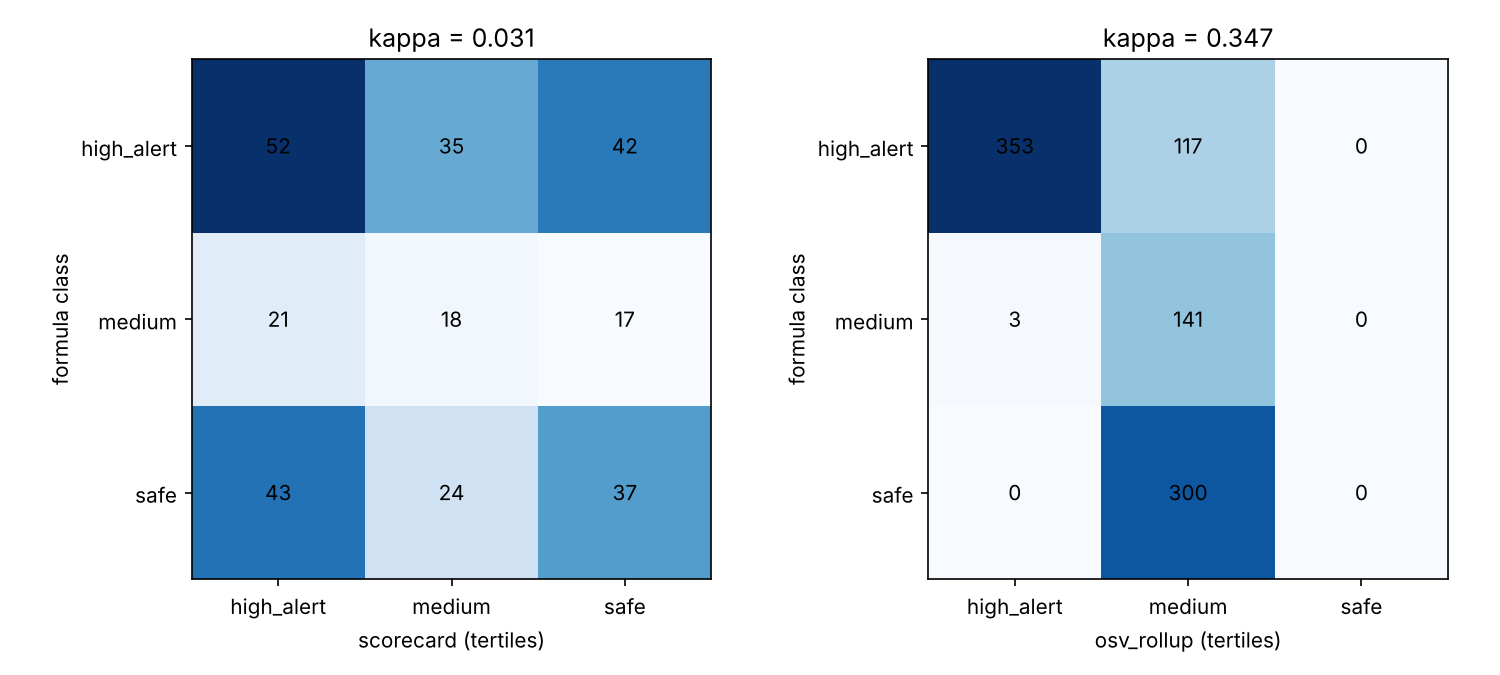

**correlation_scatter.png**

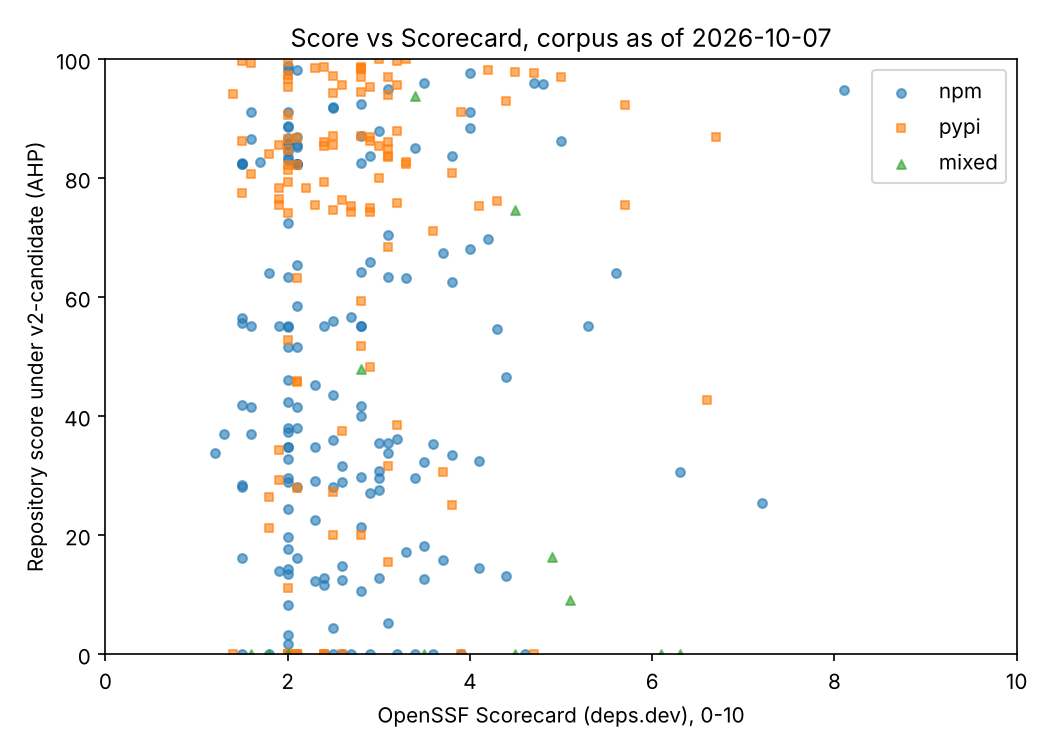

**weight_comparison.png**

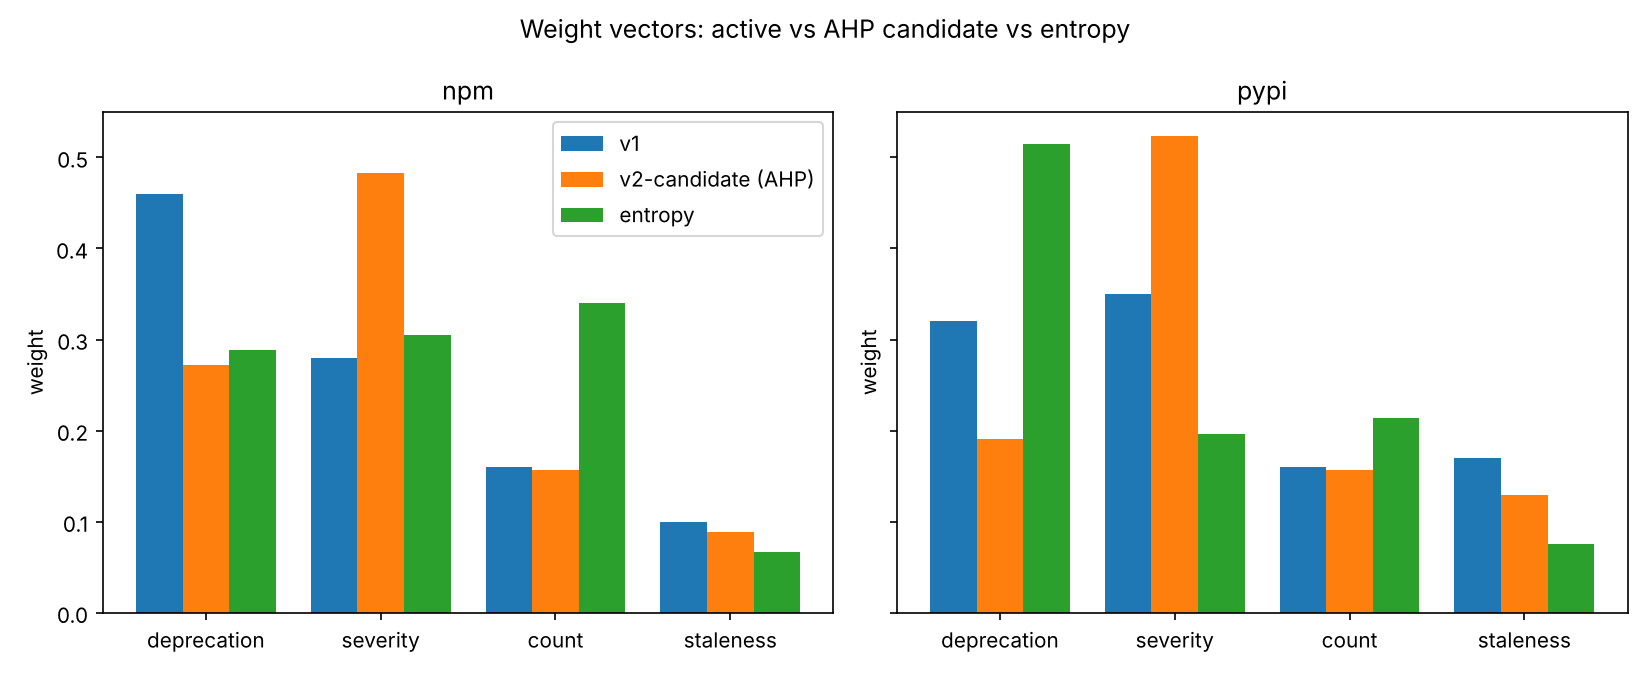

In [7]:
for figure in sorted((WORK / "validation_report").glob("*.png")):
    display(Markdown(f"**{figure.name}**"))
    display(Image(filename=str(figure)))

## 5. Exploring

File C §1.1: a reviewer's *"what if staleness were weighted double?"* is a notebook cell, not a data-collection round. Anything below this line is exploratory and is labelled so in the papers.

In [8]:
v2 = load_weights("v2")
double_staleness = replication.reweighted(v2, {"staleness": 2.0}, version="v2-staleness-x2")
display(Markdown(replication.flip_table(corpus, v2, double_staleness)))

184 of 914 repositories change class (20.1%) from `v2` to `v2-staleness-x2`.

| `v2` | `v2-staleness-x2` | Repositories |
|---|---|---|
| high_alert | high_alert | 469 |
| high_alert | medium | 1 |
| medium | high_alert | 40 |
| medium | medium | 104 |
| safe | medium | 143 |
| safe | safe | 157 |

In [9]:
import pandas as pd

scans = pd.read_parquet(EXPORT / "scan_history.parquet")
occurrences = pd.read_parquet(EXPORT / "dependency_history.parquet")
(occurrences.groupby("ecosystem")[["is_deprecated", "is_unassessable"]].mean().rename(columns=lambda c: f"share {c}"))

,share is_deprecated,share is_unassessable
ecosystem,,
npm,0.064629,0.018416
pypi,0.005195,0.034416
